### Загрузка 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_excel('dataset.xlsx', index_col=0)

In [3]:
df.head()

,Регион,Год,Объем_сточных_вод_млн_м3,Инвестиции_в_ООС,ВРП
0,Алтайский край,2000,31.0,176660.0,46736.8
1,Алтайский край,2001,34.0,111590.0,61854.4
2,Алтайский край,2002,36.0,67466.0,73107.4
3,Алтайский край,2003,36.0,50114.0,88733.3
4,Алтайский край,2004,36.0,38270.0,114840.5


**Описание колонок:**

1. **Регион** - номер ученика
2. **Год** - год.
3. **Объем_сточных_вод_млн_м3** - общий объём сточных вод (отведённой после использования воды, подлежащей очистке), выраженный в миллионах кубических метров за соответствующий год.
4. **Инвестиции_в_ООС** - вложенные финансовые средства в охрану окружающей среды (меры по снижению загрязнения, модернизации очистных сооружений и т.д.), выраженные в миллионах рублей за данный год.
5. **ВРП** - Предметы
   
Наша целевая переменная - **Инвестиции_в_ООС**.

### EDA

In [45]:
df.shape

(1992, 5)

In [47]:
df.describe()

,Год,Объем_сточных_вод_млн_м3,Инвестиции_в_ООС,ВРП
count,1992.000000,1992.000000,1.992000e+03,1.969000e+03
mean,2011.500000,187.615136,4.882114e+06,7.987815e+07
std,6.923925,265.708328,1.314931e+07,8.804387e+08
min,2000.000000,0.000000,0.000000e+00,2.618500e+03
25%,2005.750000,38.000000,2.004695e+05,9.062360e+04
50%,2011.500000,87.420000,9.408741e+05,2.580955e+05
75%,2017.250000,211.970000,3.903847e+06,6.787183e+05
max,2023.000000,2661.000000,2.517769e+08,3.233900e+10


df.isna().sum()

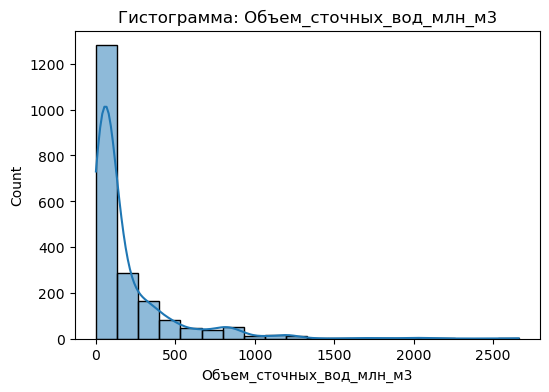

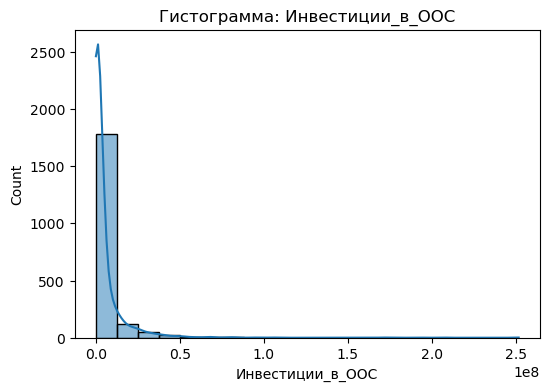

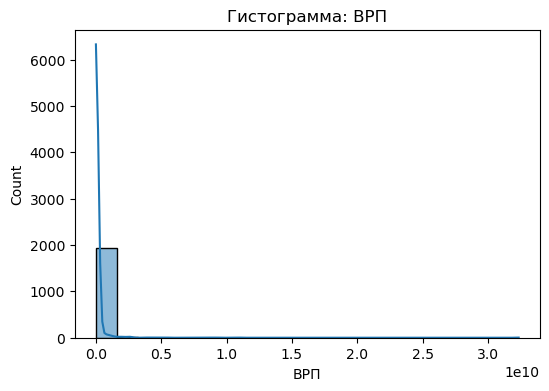

In [55]:
for col in ['Объем_сточных_вод_млн_м3', 'Инвестиции_в_ООС', 'ВРП']:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(f'Гистограмма: {col}')
    plt.show()

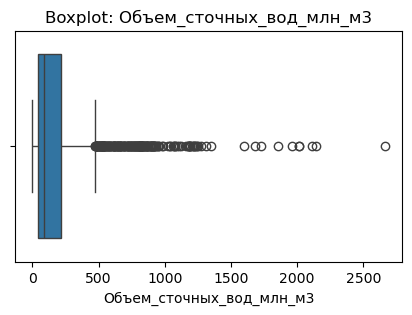

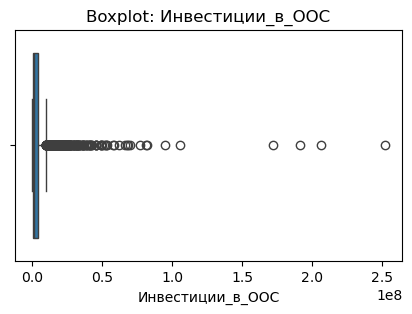

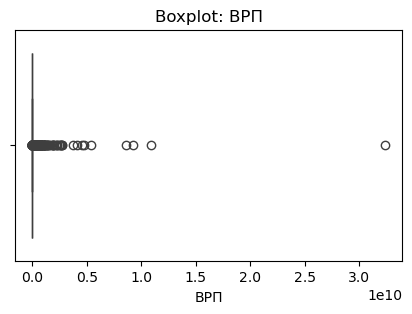

In [57]:
for col in ['Объем_сточных_вод_млн_м3', 'Инвестиции_в_ООС', 'ВРП']:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

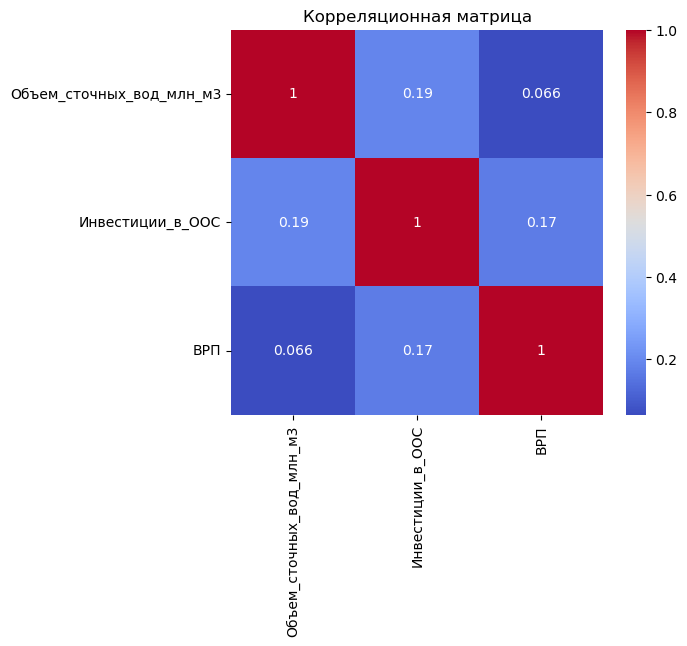

In [59]:
plt.figure(figsize=(6,5))
corr = df[['Объем_сточных_вод_млн_м3', 'Инвестиции_в_ООС', 'ВРП']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

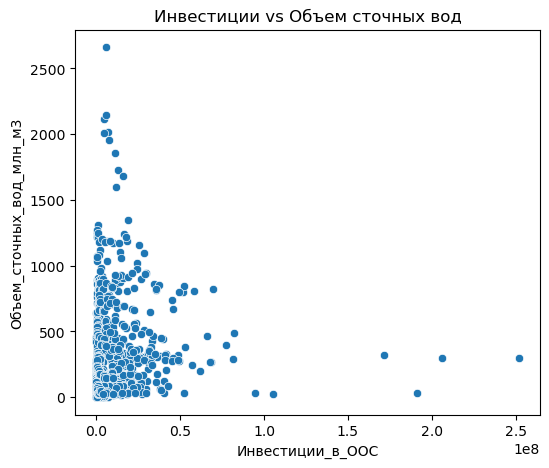

In [61]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='Инвестиции_в_ООС', y='Объем_сточных_вод_млн_м3')
plt.title('Инвестиции vs Объем сточных вод')
plt.show()

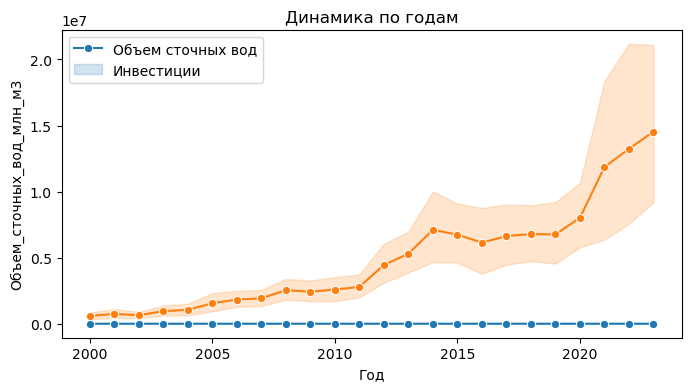

In [63]:
# 5. Временной ряд 
plt.figure(figsize=(8,4))
sns.lineplot(data=df, x='Год', y='Объем_сточных_вод_млн_м3', marker='o')
sns.lineplot(data=df, x='Год', y='Инвестиции_в_ООС', marker='o')
plt.legend(['Объем сточных вод', 'Инвестиции'])
plt.title('Динамика по годам')
plt.show()

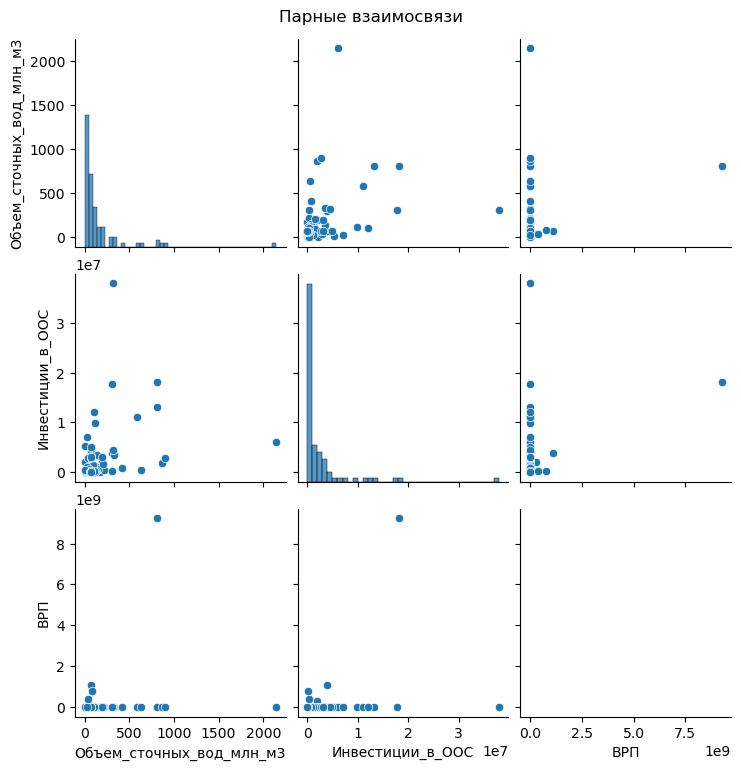

In [75]:
g = sns.pairplot(df.sample(100)[['Объем_сточных_вод_млн_м3', 'Инвестиции_в_ООС', 'ВРП']])
g.fig.suptitle('Парные взаимосвязи', y=1.02)
plt.show()


#### **Вывод**
**1.** Распределения признаков (гистограммы, boxplot)
Все три показателя ("Объем сточных вод", "Инвестиции в ООС", "ВРП") имеют выраженную правостороннюю асимметрию — большинство значений низкие, но встречаются очень крупные выбросы.

По boxplot видно много аномалий (точек-выбросов), они могут искажать статистику и качество моделей.

**2.** Динамика по годам
Инвестиции в охрану окружающей среды значительно росли, особенно после ~2010 года, а с 2020-го взрывной рост. Это может быть связано с отдельными крупными программами или проектами.

Объем сточных вод практически не меняется на фоне роста инвестиций — прямая видимого эффекта нет, либо он слабый/отложен по времени.

**3.** Взаимосвязь (scatter)
Между инвестициями и объемом сточных вод явной зависимости не видно: нет очевидного тренда "чем выше инвестиции — тем меньше сбросы".

Большинство точек — это сочетания низких инвестиций и низких объемов; отдельные случаи больших инвестиций не дают заметного снижения сбросов по точкам.

Видны выбросы: крупные инвестиции не всегда коррелируют с низкими сбросами.

Общий аналитический вывод
В данных присутствуют существенные выбросы, поэтому для корректного регрессионного анализа и выводов о влиянии инвестиций на снижение сточных вод их необходимо обработать (удалить или трансформировать).

Рост инвестиций не сопровождается явным снижением сточных вод — возможные причины: недостаточно целевые траты, временной лаг эффекта, влияние других факторов, ошибки или особенности агрегирования данных.

Для обнаружения скрытой закономерности стоит попробовать логарифмировать показатели, исключать выбросы и учитывать временные лаги при моделировании.

Основная рекомендация: модель регрессии строить на очищенных и нормализованных данных, детально анализировать влияние крупных инвестиций и регионы-лидеры.

#### Очистка выбросов

Очистка выбросов (IQR rule)

In [10]:
def remove_outliers_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

numeric_cols = ['Объем_сточных_вод_млн_м3', 'Инвестиции_в_ООС', 'ВРП']
filtered_df = remove_outliers_iqr(df, numeric_cols)
filtered_df.shape

(1386, 5)

Логарифмирование (для подавления хвостов распределения)

In [13]:
for col in numeric_cols:
    filtered_df[f'{col}_log'] = np.log1p(filtered_df[col])

In [15]:
filtered_df.head()

,Регион,Год,Объем_сточных_вод_млн_м3,Инвестиции_в_ООС,ВРП,Объем_сточных_вод_млн_м3_log,Инвестиции_в_ООС_log,ВРП_log
0,Алтайский край,2000,31.0,176660.0,46736.8,3.465736,12.081988,10.752309
1,Алтайский край,2001,34.0,111590.0,61854.4,3.555348,11.622596,11.032555
2,Алтайский край,2002,36.0,67466.0,73107.4,3.610918,11.119394,11.199699
3,Алтайский край,2003,36.0,50114.0,88733.3,3.610918,10.822076,11.393402
4,Алтайский край,2004,36.0,38270.0,114840.5,3.610918,10.552448,11.651308


Нормализация инвестиций по ВРП

In [18]:
filtered_df['Инвестиции_норм'] = filtered_df['Инвестиции_в_ООС'] / filtered_df['ВРП']
filtered_df['Инвестиции_норм_log'] = np.log1p(filtered_df['Инвестиции_норм'])

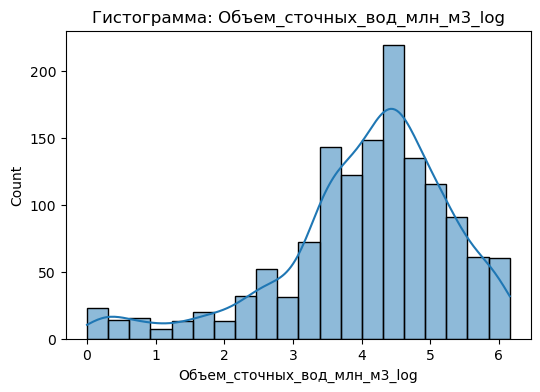

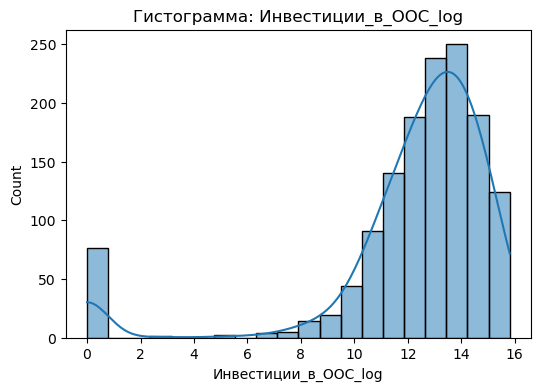

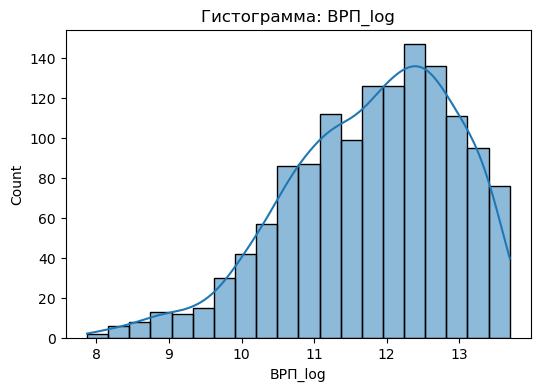

In [30]:
for col in ['Объем_сточных_вод_млн_м3_log', 'Инвестиции_в_ООС_log', 'ВРП_log']:
    plt.figure(figsize=(6,4))
    sns.histplot(filtered_df[col], bins=20, kde=True)
    plt.title(f'Гистограмма: {col}')
    plt.show()

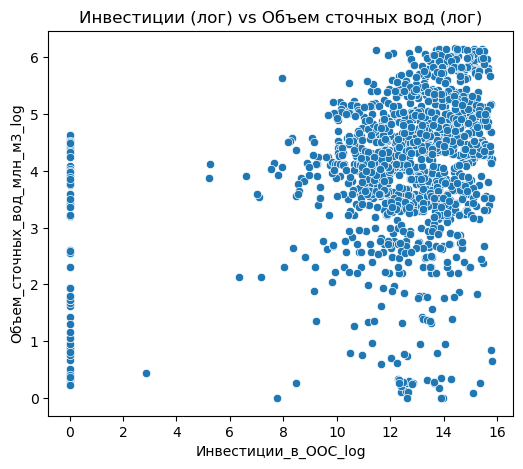

In [34]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=filtered_df['Инвестиции_в_ООС_log'], y=filtered_df['Объем_сточных_вод_млн_м3_log'])
plt.title('Инвестиции (лог) vs Объем сточных вод (лог)')
plt.show()

### Построение моделей

#### Линейная регрессия

In [38]:
import statsmodels.api as sm

X = filtered_df['Инвестиции_в_ООС_log']
y = filtered_df['Объем_сточных_вод_млн_м3_log']

X = sm.add_constant(X)

model = sm.OLS(y, X)
results = model.fit()

print(results.summary())


                                 OLS Regression Results                                 
Dep. Variable:     Объем_сточных_вод_млн_м3_log   R-squared:                       0.122
Model:                                      OLS   Adj. R-squared:                  0.121
Method:                           Least Squares   F-statistic:                     191.9
Date:                          Mon, 27 Oct 2025   Prob (F-statistic):           5.68e-41
Time:                                  23:10:40   Log-Likelihood:                -2177.2
No. Observations:                          1386   AIC:                             4358.
Df Residuals:                              1384   BIC:                             4369.
Df Model:                                     1                                         
Covariance Type:                      nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
---------------------

In [40]:
X = filtered_df[['Инвестиции_в_ООС_log', 'ВРП_log']]
X = sm.add_constant(X)
y = filtered_df['Объем_сточных_вод_млн_м3_log']
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())


                                 OLS Regression Results                                 
Dep. Variable:     Объем_сточных_вод_млн_м3_log   R-squared:                       0.167
Model:                                      OLS   Adj. R-squared:                  0.166
Method:                           Least Squares   F-statistic:                     138.4
Date:                          Mon, 27 Oct 2025   Prob (F-statistic):           1.68e-55
Time:                                  23:10:44   Log-Likelihood:                -2140.9
No. Observations:                          1386   AIC:                             4288.
Df Residuals:                              1383   BIC:                             4303.
Df Model:                                     2                                         
Covariance Type:                      nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
---------------------

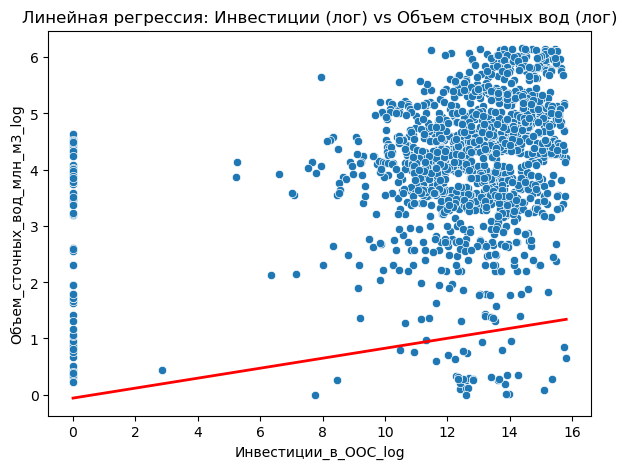

In [42]:
import numpy as np

plt.figure(figsize=(7,5))
sns.scatterplot(x=filtered_df['Инвестиции_в_ООС_log'], y=filtered_df['Объем_сточных_вод_млн_м3_log'])
x_vals = np.linspace(filtered_df['Инвестиции_в_ООС_log'].min(), filtered_df['Инвестиции_в_ООС_log'].max(), 100)
y_pred = results.params['const'] + results.params['Инвестиции_в_ООС_log'] * x_vals
plt.plot(x_vals, y_pred, color='red', linewidth=2)
plt.title('Линейная регрессия: Инвестиции (лог) vs Объем сточных вод (лог)')
plt.show()


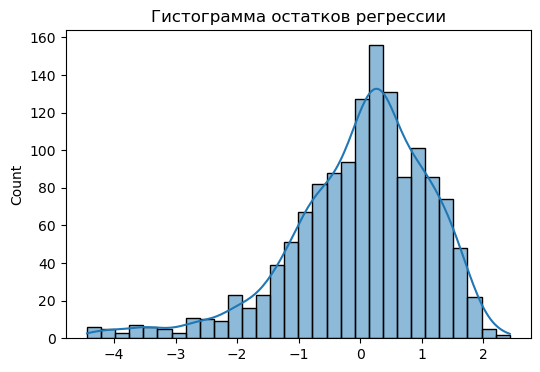

In [44]:
residuals = results.resid
plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=30, kde=True)
plt.title('Гистограмма остатков регрессии')
plt.show()


#### 2

In [47]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

X = filtered_df[['Инвестиции_в_ООС_log', 'ВРП_log']]
y = filtered_df['Объем_сточных_вод_млн_м3_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print('R2:', r2_score(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))

print('Feature importances:', rf.feature_importances_)

R2: 0.19429358674061015
MSE: 1.2613075247818286
Feature importances: [0.49365359 0.50634641]


In [49]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

X = filtered_df[['Инвестиции_в_ООС_log', 'ВРП_log']]
y = filtered_df['Объем_сточных_вод_млн_м3_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

xgb = XGBRegressor(n_estimators=100, max_depth=5, random_state=42)
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
print('R2:', r2_score(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))

print('Feature importances:', xgb.feature_importances_)

R2: 0.03887668398423061
MSE: 1.5046076967785948
Feature importances: [0.49023727 0.50976276]
